In [1]:
# To install basic/necessary libraries
# Run this in a notebook cell with "!" to install via shell
!pip install pandas numpy matplotlib seaborn scikit-learn




[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install scikit-learn
import pandas as pd
import numpy as np

from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score




[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# load the dataset
# Load CSV (adjust sep if needed)
df = pd.read_csv('PB_All_2000_2021.csv', sep=';')  # or sep=','
df.head()


,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,17.02.2000,0.330,2.77,12.0,12.30,9.50,0.057,154.0,0.454,289.5
1,1,11.05.2000,0.044,3.00,51.6,14.61,17.75,0.034,352.0,0.090,1792.0
2,1,11.09.2000,0.032,2.10,24.5,9.87,13.80,0.173,416.0,0.200,2509.0
3,1,13.12.2000,0.170,2.23,35.6,12.40,17.13,0.099,275.2,0.377,1264.0
4,1,02.03.2001,0.000,3.03,48.8,14.69,10.00,0.065,281.6,0.134,1462.0


In [4]:
df.info() # dataset info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2861 entries, 0 to 2860
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         2861 non-null   int64  
 1   date       2861 non-null   object 
 2   NH4        2858 non-null   float64
 3   BSK5       2860 non-null   float64
 4   Suspended  2845 non-null   float64
 5   O2         2858 non-null   float64
 6   NO3        2860 non-null   float64
 7   NO2        2858 non-null   float64
 8   SO4        2812 non-null   float64
 9   PO4        2833 non-null   float64
 10  CL         2812 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 246.0+ KB


In [5]:
# rows and cols
df.shape

(2861, 11)

In [6]:
# Statistics of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2861.0,12.397064,6.084226,1.00,8.0000,14.000,16.00000,22.000
NH4,2858.0,0.758734,2.486247,0.00,0.0800,0.220,0.50000,39.427
BSK5,2860.0,4.316182,2.973997,0.00,2.1600,3.800,5.80000,50.900
Suspended,2845.0,12.931905,16.543097,0.00,6.0000,10.000,15.00000,595.000
O2,2858.0,9.508902,4.428260,0.00,7.0925,8.995,11.52000,90.000
NO3,2860.0,4.316846,6.881188,0.00,1.3900,2.800,5.58250,133.400
NO2,2858.0,0.246128,2.182777,0.00,0.0300,0.059,0.12575,109.000
SO4,2812.0,59.362313,96.582641,0.00,27.0525,37.800,64.64000,3573.400
PO4,2833.0,0.418626,0.771326,0.00,0.1300,0.270,0.47000,13.879
CL,2812.0,93.731991,394.512184,0.02,26.8000,33.900,45.60750,5615.280


In [7]:
# Missing values
df.isnull().sum()

id            0
date          0
NH4           3
BSK5          1
Suspended    16
O2            3
NO3           1
NO2           3
SO4          49
PO4          28
CL           49
dtype: int64

In [8]:
# date is in object - date format
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
df

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.00,0.454,289.50
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.00,0.090,1792.00
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.00,0.200,2509.00
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.20,0.377,1264.00
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.60,0.134,1462.00
...,...,...,...,...,...,...,...,...,...,...,...
2856,22,2020-10-06,0.046,2.69,3.6,8.28,3.80,0.038,160.00,0.726,77.85
2857,22,2020-10-27,0.000,1.52,0.5,11.26,0.56,0.031,147.20,0.634,71.95
2858,22,2020-12-03,0.034,0.29,0.8,11.09,2.58,0.042,209.92,0.484,61.17
2859,22,2021-01-12,0.000,2.10,0.0,14.31,3.94,0.034,121.60,0.424,63.49


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2861 entries, 0 to 2860
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         2861 non-null   int64         
 1   date       2861 non-null   datetime64[ns]
 2   NH4        2858 non-null   float64       
 3   BSK5       2860 non-null   float64       
 4   Suspended  2845 non-null   float64       
 5   O2         2858 non-null   float64       
 6   NO3        2860 non-null   float64       
 7   NO2        2858 non-null   float64       
 8   SO4        2812 non-null   float64       
 9   PO4        2833 non-null   float64       
 10  CL         2812 non-null   float64       
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 246.0 KB


In [10]:
df = df.sort_values(by=['id', 'date'])
df.head()

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.0,0.454,289.5
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.0,0.090,1792.0
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.0,0.200,2509.0
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.2,0.377,1264.0
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.6,0.134,1462.0


In [11]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [12]:
df.head()

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL,year,month
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.0,0.454,289.5,2000,2
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.0,0.090,1792.0,2000,5
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.0,0.200,2509.0,2000,9
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.2,0.377,1264.0,2000,12
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.6,0.134,1462.0,2001,3


In [13]:
df.columns

Index(['id', 'date', 'NH4', 'BSK5', 'Suspended', 'O2', 'NO3', 'NO2', 'SO4',
       'PO4', 'CL', 'year', 'month'],
      dtype='object')

In [14]:
pollutants = ['O2', 'NO3', 'NO2', 'SO4',
       'PO4', 'CL']

In [22]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

pollutants = ['O2', 'NO3', 'NO2', 'SO4', 'PO4', 'CL']

df = df.dropna()

X = df.drop(columns=pollutants)
y = df[pollutants]

# remove all date/time columns
date_columns = X.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns
X = X.drop(columns=date_columns)

# convert text columns into numbers
X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=100, random_state=42)
)

model.fit(X_train, y_train)

joblib.dump(model, "pollution_model.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Model saved successfully!")

Model saved successfully!


In [23]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("PB_All_2000_2021.csv", sep=";")
df.columns = df.columns.str.strip()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

features = ["id", "year", "month", "NH4", "BSK5", "Suspended"]
targets = ["O2", "NO3", "NO2", "SO4", "PO4", "CL"]

df_model = df[features + targets].dropna()

X = df_model[features]
y = df_model[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=200, random_state=42)
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

joblib.dump(model, "pollution_model.pkl")
joblib.dump(features, "model_columns.pkl")

print("New improved model saved successfully!")

C:\Users\aygho\AppData\Local\Temp\ipykernel_12584\2875435686.py:12: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


R2 Score: 0.5825490641944253
MSE: 1891.3845262198456
New improved model saved successfully!


In [24]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv("PB_All_2000_2021.csv", sep=";")
df.columns = df.columns.str.strip()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

features = ["id", "year", "month", "NH4", "BSK5", "Suspended"]
targets = ["O2", "NO3", "NO2", "SO4", "PO4", "CL"]

df_model = df[features + targets].dropna()

X = df_model[features]
y = df_model[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": MultiOutputRegressor(LinearRegression()),
    "Random Forest": MultiOutputRegressor(RandomForestRegressor(n_estimators=300, random_state=42)),
    "Extra Trees": MultiOutputRegressor(ExtraTreesRegressor(n_estimators=300, random_state=42)),
    "Gradient Boosting": MultiOutputRegressor(GradientBoostingRegressor(random_state=42))
}

results = []

best_model = None
best_score = -999
best_model_name = ""

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

    if r2 > best_score:
        best_score = r2
        best_model = model
        best_model_name = name

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)

print(results_df)
print("\nBest Model:", best_model_name)

joblib.dump(best_model, "pollution_model.pkl")
joblib.dump(features, "model_columns.pkl")
joblib.dump(results_df, "model_comparison.pkl")

print("Best model and comparison results saved successfully!")

C:\Users\aygho\AppData\Local\Temp\ipykernel_12584\1128898647.py:14: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


               Model  R2 Score        MAE        RMSE
1      Random Forest  0.585568   5.938433   44.651924
2        Extra Trees  0.245180   6.309233   49.544616
3  Gradient Boosting  0.214572   6.362599   41.449246
0  Linear Regression  0.183134  30.039826  133.368928

Best Model: Random Forest
Best model and comparison results saved successfully!


     Feature  Importance
4       BSK5    0.265548
2      month    0.179311
5  Suspended    0.162246
0         id    0.159298
1       year    0.120960
3        NH4    0.112637


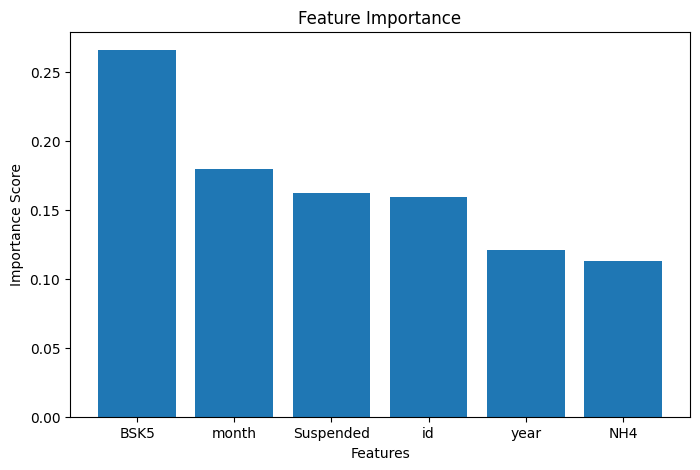

Feature importance saved successfully!


In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import joblib

rf_model = best_model.estimators_[0]

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

joblib.dump(importance_df, "feature_importance.pkl")

plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

print("Feature importance saved successfully!")

In [3]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor


class HybridRFXGB:
    def __init__(self, rf_model, xgb_model, rf_weight=0.5, xgb_weight=0.5):
        self.rf_model = rf_model
        self.xgb_model = xgb_model
        self.rf_weight = rf_weight
        self.xgb_weight = xgb_weight

    def fit(self, X, y):
        self.rf_model.fit(X, y)
        self.xgb_model.fit(X, y)
        return self

    def predict(self, X):
        rf_pred = self.rf_model.predict(X)
        xgb_pred = self.xgb_model.predict(X)
        return (self.rf_weight * rf_pred) + (self.xgb_weight * xgb_pred)


df = pd.read_csv("PB_All_2000_2021.csv", sep=";")
df.columns = df.columns.str.strip()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

features = ["id", "year", "month", "NH4", "BSK5", "Suspended"]
targets = ["O2", "NO3", "NO2", "SO4", "PO4", "CL"]

df_model = df[features + targets].dropna()

X = df_model[features]
y = df_model[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": MultiOutputRegressor(LinearRegression()),

    "Random Forest": MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )
    ),

    "Extra Trees": MultiOutputRegressor(
        ExtraTreesRegressor(
            n_estimators=300,
            random_state=42
        )
    ),

    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            random_state=42
        )
    ),

    "XGBoost": MultiOutputRegressor(
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=42
        )
    ),

    "Hybrid RF + XGBoost": HybridRFXGB(
        rf_model=MultiOutputRegressor(
            RandomForestRegressor(
                n_estimators=300,
                random_state=42
            )
        ),
        xgb_model=MultiOutputRegressor(
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="reg:squarederror",
                random_state=42
            )
        ),
        rf_weight=0.5,
        xgb_weight=0.5
    )
}

results = []

best_model = None
best_score = -999
best_model_name = ""

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

    if r2 > best_score:
        best_score = r2
        best_model = model
        best_model_name = name

results_df = pd.DataFrame(results).sort_values(
    by="R2 Score",
    ascending=False
)

print(results_df)
print("\nBest Model:", best_model_name)
print("Best R2 Score:", best_score)

joblib.dump(best_model, "pollution_model.pkl")
joblib.dump(features, "model_columns.pkl")
joblib.dump(results_df, "model_comparison.pkl")
joblib.dump(best_model_name, "best_model_name.pkl")

print("Hybrid training completed and best model saved successfully!")

C:\Users\aygho\AppData\Local\Temp\ipykernel_9316\3846849858.py:35: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


                 Model  R2 Score        MAE        RMSE
5  Hybrid RF + XGBoost  0.621565   5.834776   41.914743
4              XGBoost  0.608436   6.144774   42.462419
1        Random Forest  0.585568   5.938433   44.651924
2          Extra Trees  0.245180   6.309233   49.544616
3    Gradient Boosting  0.214572   6.362599   41.449246
0    Linear Regression  0.183134  30.039826  133.368928

Best Model: Hybrid RF + XGBoost
Best R2 Score: 0.6215653508658174
Hybrid training completed and best model saved successfully!


In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


class HybridRFXGB:
    def __init__(self, rf_model, xgb_model, rf_weight=0.5, xgb_weight=0.5):
        self.rf_model = rf_model
        self.xgb_model = xgb_model
        self.rf_weight = rf_weight
        self.xgb_weight = xgb_weight

    def fit(self, X, y):
        self.rf_model.fit(X, y)
        self.xgb_model.fit(X, y)
        return self

    def predict(self, X):
        rf_pred = self.rf_model.predict(X)
        xgb_pred = self.xgb_model.predict(X)
        return self.rf_weight * rf_pred + self.xgb_weight * xgb_pred


def clip_outliers_iqr(df, cols):
    df = df.copy()
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df[col] = df[col].clip(lower, upper)
    return df


df = pd.read_csv("PB_All_2000_2021.csv", sep=";")
df.columns = df.columns.str.strip()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

features_base = ["id", "year", "month", "NH4", "BSK5", "Suspended"]
targets = ["O2", "NO3", "NO2", "SO4", "PO4", "CL"]

df_model = df[features_base + targets].dropna()

# 1. Outlier handling
numeric_cols = features_base + targets
df_model = clip_outliers_iqr(df_model, numeric_cols)

# 2. Feature engineering
df_model["season"] = df_model["month"].map({
    12: 1, 1: 1, 2: 1,
    3: 2, 4: 2, 5: 2,
    6: 3, 7: 3, 8: 3, 9: 3,
    10: 4, 11: 4
})

df_model["pollution_load"] = df_model["NH4"] + df_model["BSK5"] + df_model["Suspended"]
df_model["organic_solid_interaction"] = df_model["BSK5"] * df_model["Suspended"]
df_model["nh4_bsk5_interaction"] = df_model["NH4"] * df_model["BSK5"]
df_model["log_suspended"] = np.log1p(df_model["Suspended"])
df_model["log_bsk5"] = np.log1p(df_model["BSK5"])

features = [
    "id", "year", "month", "season",
    "NH4", "BSK5", "Suspended",
    "pollution_load",
    "organic_solid_interaction",
    "nh4_bsk5_interaction",
    "log_suspended",
    "log_bsk5"
]

X = df_model[features]
y = df_model[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []
best_model = None
best_score = -999
best_model_name = ""

# 3. Tuned models
model_candidates = {}

model_candidates["Random Forest Tuned"] = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
)

model_candidates["Extra Trees Tuned"] = MultiOutputRegressor(
    ExtraTreesRegressor(
        n_estimators=500,
        max_depth=14,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
)

model_candidates["XGBoost Tuned"] = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2,
        reg_alpha=0.1,
        objective="reg:squarederror",
        random_state=42
    )
)

# 4. Hybrid weight search
weights = [
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6),
    (0.3, 0.7)
]

for rf_w, xgb_w in weights:
    model_candidates[f"Hybrid RF({rf_w}) + XGB({xgb_w})"] = HybridRFXGB(
        rf_model=MultiOutputRegressor(
            RandomForestRegressor(
                n_estimators=500,
                max_depth=12,
                min_samples_split=4,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        ),
        xgb_model=MultiOutputRegressor(
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_lambda=2,
                reg_alpha=0.1,
                objective="reg:squarederror",
                random_state=42
            )
        ),
        rf_weight=rf_w,
        xgb_weight=xgb_w
    )

for name, model in model_candidates.items():
    print("Training:", name)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

    if r2 > best_score:
        best_score = r2
        best_model = model
        best_model_name = name

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)

print(results_df)
print("\nBest Model:", best_model_name)
print("Best R2 Score:", best_score)

joblib.dump(best_model, "pollution_model.pkl")
joblib.dump(features, "model_columns.pkl")
joblib.dump(results_df, "model_comparison.pkl")
joblib.dump(best_model_name, "best_model_name.pkl")

print("Optimized hybrid experiment completed successfully!")

C:\Users\aygho\AppData\Local\Temp\ipykernel_9316\2683923850.py:45: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


Training: Random Forest Tuned
Training: Extra Trees Tuned
Training: XGBoost Tuned
Training: Hybrid RF(0.7) + XGB(0.3)
Training: Hybrid RF(0.6) + XGB(0.4)
Training: Hybrid RF(0.5) + XGB(0.5)
Training: Hybrid RF(0.4) + XGB(0.6)
Training: Hybrid RF(0.3) + XGB(0.7)
                       Model  R2 Score       MAE      RMSE
6  Hybrid RF(0.4) + XGB(0.6)  0.560519  2.997643  6.657536
1          Extra Trees Tuned  0.560330  3.099771  7.006280
5  Hybrid RF(0.5) + XGB(0.5)  0.560171  2.998729  6.695895
7  Hybrid RF(0.3) + XGB(0.7)  0.559917  3.001531  6.628141
4  Hybrid RF(0.6) + XGB(0.4)  0.558873  3.002307  6.743065
3  Hybrid RF(0.7) + XGB(0.3)  0.556626  3.009456  6.798861
2              XGBoost Tuned  0.552414  3.030515  6.594750
0        Random Forest Tuned  0.544185  3.063084  7.015795

Best Model: Hybrid RF(0.4) + XGB(0.6)
Best R2 Score: 0.5605187732831668
Optimized hybrid experiment completed successfully!
